In [213]:
#!python -m pip install --upgrade pip
#%pip install pandas matplotlib seaborn scikit-learn openpyxl tensorflow xgboost aif360
#%pip install "aif360[Reductions, inFairness]"

In [ ]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, BatchNormalization # type: ignore

from aif360.datasets import StandardDataset
from fairlearn.preprocessing import CorrelationRemover
from aif360.algorithms.inprocessing import GerryFairClassifier
from fairlearn.postprocessing import ThresholdOptimizer

from pandas.plotting import parallel_coordinates

import pickle

random_seed = 42

In [281]:
PATH = 'C:/Users/andre/Desktop/ProjectWork_AEQUITAS_AKKODIS/'
df = (
    pd.read_excel(PATH + 'data/Dataset_Preprocessed.xlsx')
)
df.head()

,Candidate State,Age Range,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,Job Title Hiring,...,Dynamism,Mobility,English,Residence City,Residence Province,Residence Region,Residence State,European Residence,Italian Residence,Status
0,Hired,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[1-3],Automotive,Engineering,Consultant,...,3,2,4,TURIN,Turin,Piedmont,ITALY,Yes,Yes,Positive
1,Vivier,40 - 45 years,Female,Not a protected category,Engineering,Five-year degree,[7-10],Aeronautics,Not Specified,Not Specified,...,2,2,3,CONVERSANO,Bari,Puglia,ITALY,Yes,Yes,Negative
2,QM,36 - 40 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Consulting,Not Specified,Not Specified,...,2,2,3,CASERTA,Caserta,Campania,ITALY,Yes,Yes,Positive
3,QM,> 45 years,Male,Not a protected category,Law,Five-year degree,[7-10],Telecom,Not Specified,Not Specified,...,2,2,3,SESTO SAN GIOVANNI,Milan,Lombardy,ITALY,Yes,Yes,Positive
4,In selection,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Automotive,Not Specified,Not Specified,...,3,1,1,ARA,Trapani,Sicily,ITALY,Yes,Yes,Negative


In [282]:
config = {}
config['categorical_columns_custom_orders'] = {
    'Sex' : ['Female', 'Male'],
    'Status' : ['Negative', 'Positive'],
    'Italian Residence': ['No', 'Yes'],
    'Candidate State': ['Not Specified', 'Imported', 'First contact', 'In selection', 'QM', 'Vivier', 'Economic proposal', 'Hired'],
    'Age Range': ['Not Specified', '< 20 years', '20 - 25 years', '26 - 30 years', '31 - 35 years', '36 - 40 years', '40 - 45 years', '> 45 years'],
    'Years Experience': ['Not Specified', '[0]', '[0-1]', '[1-3]', '[3-5]', '[5-7]', '[7-10]', '[+10]'],
    'Study Title': ['Not Specified', 'Middle school diploma', 'High school graduation', 'Professional qualification', 'Three-year degree', 'master\'s degree', 'Five-year degree', 'Doctorate'],
    'Study Level': ['Not Specified', 'Middle school diploma', 'High school graduation', 'Professional qualification', 'Three-year degree', 'master\'s degree', 'Five-year degree', 'Doctorate'],
    'Current Ral': ['Not Specified', 'Not available', '- 20 K', '20-22 K', '22-24 K', '24-26 K', '26-28 K', '28-30 K', '30-32 K', '32-34 K', '34-36 K', '36-38 K', '38-40 K', '40-42 K', '42-44 K', '44-46 K', '46-48 K', '48-50 K', '+ 50 K'],
    'Expected Ral': ['Not Specified', 'Not available', '- 20 K', '20-22 K', '22-24 K', '24-26 K', '26-28 K', '28-30 K', '30-32 K', '32-34 K', '34-36 K', '36-38 K', '38-40 K', '40-42 K', '42-44 K', '44-46 K', '46-48 K', '48-50 K', '+ 50 K'],
    'Ral Maximum': ['Not Specified', 'Not Avail.', '- 20K', '20K', '20-22K', '22-24K', '24-26K', '26-28K', '28-30K', '30-32K', '32-34K', '34-36K', '36-38K', '38-40K', '40-42K', '42-44K', '44-46K', '46-48K', '48-50k', '+50K'],
    'Minimum Ral': ['Not Specified', 'Not Avail.', '- 20K', '20K', '20-22K', '22-24K', '24-26K', '26-28K', '28-30K', '30-32K', '32-34K', '34-36K', '36-38K', '38-40K', '40-42K', '42-44K', '44-46K', '46-48K', '48-50K', '+50K'],
    'Overall' : ['Not Specified', '~ 1 - Low', '1 - Low', '~ 2 - Medium', '2 - Medium', '~ 3 - High', '3 - High', '~ 4 - Top', '4 - Top']
}

In [283]:
columns_type = {}
for col in df.columns:
    if pd.api.types.is_string_dtype(df[col]):
        columns_type[col] = 'cat'
    elif pd.api.types.is_numeric_dtype(df[col]):
        columns_type[col] = 'num'
pprint(columns_type)

{'Age Range': 'cat',
 'Candidate State': 'cat',
 'Comunication': 'num',
 'Current Ral': 'cat',
 'Dynamism': 'num',
 'English': 'num',
 'European Residence': 'cat',
 'Event_Feedback': 'cat',
 'Expected Ral': 'cat',
 'Italian Residence': 'cat',
 'Job Family Hiring': 'cat',
 'Job Title Hiring': 'cat',
 'Maturity': 'num',
 'Minimum Ral': 'cat',
 'Mobility': 'num',
 'Overall': 'cat',
 'Protected Category': 'cat',
 'Ral Maximum': 'cat',
 'Residence City': 'cat',
 'Residence Province': 'cat',
 'Residence Region': 'cat',
 'Residence State': 'cat',
 'Sector': 'cat',
 'Sex': 'cat',
 'Status': 'cat',
 'Study Area': 'cat',
 'Study Level': 'cat',
 'Study Title': 'cat',
 'Technical Skills': 'num',
 'Years Experience': 'cat'}


In [284]:
encoding_mappings = {}
for col in [col for col, t in columns_type.items() if t == 'cat']:
    if col in config['categorical_columns_custom_orders']:
        df[col] = pd.Categorical(df[col], categories=config['categorical_columns_custom_orders'][col], ordered=True).codes
        encoding_mappings[col] = {cat: i for i, cat in enumerate(config['categorical_columns_custom_orders'][col])}
    else:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col].astype(str))
        encoding_mappings[col] = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
df.head()

,Candidate State,Age Range,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,Job Title Hiring,...,Dynamism,Mobility,English,Residence City,Residence Province,Residence Region,Residence State,European Residence,Italian Residence,Status
0,7,4,1,0,1,6,3,1,3,5,...,3,2,4,689,102,13,14,1,1,1
1,5,6,0,0,1,6,6,0,4,8,...,2,2,3,218,8,14,14,1,1,0
2,4,5,1,0,1,6,4,2,4,8,...,2,2,3,157,22,4,14,1,1,1
3,4,7,1,0,3,6,6,13,4,8,...,2,2,3,636,57,9,14,1,1,1
4,3,4,1,0,1,6,4,1,4,8,...,3,1,1,39,98,16,14,1,1,0


## Train

In [286]:
target = 'Status'
sensitive = ['Sex', 'Italian Residence']

In [ ]:
n_splits = 2
n_repeats = 3
cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_seed)

### Dataset Preparation

In [288]:
df = shuffle(df, random_state=random_seed)

X_train = df.drop(columns=[target])
y_train = df[target]
s_train = df[sensitive]

#X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(X_train, y_train, s_train, test_size=0.9, random_state=random_seed, stratify=y)

In [222]:
def to_aif360(X_df, y_df, s_df):
    df = X_df.copy()
    df[target] = y_df.values
    df[sensitive] = s_df.values
        
    return StandardDataset(
        df,
        label_name=target,
        favorable_classes=[1], # the value considered favorable (1)
        protected_attribute_names=sensitive,
        privileged_classes=[[1] for _ in sensitive] # values considered privileged
    )

In [223]:
predictions = {}
references = {}
sensitives = {}

### No-Processing

In [224]:
def create_model(seed, input_dim):
    tf.random.set_seed(seed)
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models = {
    'Logistic Regression': LogisticRegression(),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(),
    'KNN': KNeighborsClassifier(),
    'Neural Network': create_model(random_seed, X_train.shape[1]),
}

In [225]:
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train, s_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    s_tr, s_va = s_train.iloc[tr_idx], s_train.iloc[va_idx]

    for model_name, model in models.items():
        print(f"Training {model_name}...")
        if model_name == 'Neural Network':
            model.fit(X_tr, y_tr, epochs=20, batch_size=32, verbose=0)
            predictions[(fold, model_name)] = model.predict(X_va).ravel()
        else:
            model.fit(X_tr, y_tr)
            predictions[(fold, model_name)] = model.predict(X_va).ravel()

        predictions[(fold, model_name)] = (predictions[(fold, model_name)] > 0.5).astype(int)
        
        references[(fold, model_name)] = y_va.values
        sensitives[(fold, model_name)] = s_va.values

        print(f"{model_name} trained.")
        print(f"Predictions fold {fold} for {model_name}: {predictions[(fold, model_name)]}")

Training Logistic Regression...


c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained.
Predictions fold 1 for Logistic Regression: [1 1 0 ... 0 1 1]
Training Linear Regression...
Linear Regression trained.
Predictions fold 1 for Linear Regression: [1 1 0 ... 0 0 1]
Training Decision Tree...
Decision Tree trained.
Predictions fold 1 for Decision Tree: [1 1 0 ... 0 1 1]
Training Naive Bayes...
Naive Bayes trained.
Predictions fold 1 for Naive Bayes: [1 1 0 ... 0 0 1]
Training XGBoost...
XGBoost trained.
Predictions fold 1 for XGBoost: [1 1 0 ... 0 1 1]
Training KNN...
KNN trained.
Predictions fold 1 for KNN: [0 1 1 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 1s 4ms/step
Neural Network trained.
Predictions fold 1 for Neural Network: [1 1 0 ... 1 1 1]
Training Logistic Regression...
Logistic Regression trained.
Predictions fold 2 for Logistic Regression: [0 0 0 ... 1 0 0]
Training Linear Regression...
Linear Regression trained.
Predictions fold 2 for Linear Regression: [0 0 0 ... 0 0 0]
Training Decision Tree...

c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision Tree trained.
Predictions fold 2 for Decision Tree: [0 0 0 ... 1 0 0]
Training Naive Bayes...
Naive Bayes trained.
Predictions fold 2 for Naive Bayes: [0 0 0 ... 0 0 0]
Training XGBoost...
XGBoost trained.
Predictions fold 2 for XGBoost: [0 0 0 ... 1 0 0]
Training KNN...
KNN trained.
Predictions fold 2 for KNN: [0 0 0 ... 1 0 0]
Training Neural Network...
41/41 [==============================] - 0s 4ms/step
Neural Network trained.
Predictions fold 2 for Neural Network: [0 0 0 ... 1 0 0]
Training Logistic Regression...
Logistic Regression trained.
Predictions fold 3 for Logistic Regression: [0 1 0 ... 0 0 0]
Training Linear Regression...
Linear Regression trained.
Predictions fold 3 for Linear Regression: [0 1 0 ... 0 0 0]
Training Decision Tree...
Decision Tree trained.
Predictions fold 3 for Decision Tree: [0 1 0 ... 0 0 0]
Training Naive Bayes...
Naive Bayes trained.
Predictions fold 3 for Naive Bayes: [0 1 0 ... 0 0 0]
Training XGBoost...


...

Logistic Regression trained.
Predictions fold 4 for Logistic Regression: [1 1 0 ... 0 1 1]
Training Linear Regression...
Linear Regression trained.
Predictions fold 4 for Linear Regression: [1 1 0 ... 0 0 1]
Training Decision Tree...
Decision Tree trained.
Predictions fold 4 for Decision Tree: [1 1 0 ... 0 1 1]
Training Naive Bayes...
Naive Bayes trained.
Predictions fold 4 for Naive Bayes: [1 1 0 ... 0 0 1]
Training XGBoost...
XGBoost trained.
Predictions fold 4 for XGBoost: [1 1 0 ... 0 1 1]
Training KNN...
KNN trained.
Predictions fold 4 for KNN: [0 1 0 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 0s 4ms/step
Neural Network trained.
Predictions fold 4 for Neural Network: [1 1 0 ... 1 1 1]
Training Logistic Regression...
Logistic Regression trained.
Predictions fold 5 for Logistic Regression: [1 0 0 ... 1 0 1]
Training Linear Regression...
Linear Regression trained.
Predictions fold 5 for Linear Regression: [1 0 0 ... 0 0 1]
Training Decision Tree...

c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGBoost trained.
Predictions fold 5 for XGBoost: [1 0 0 ... 1 0 1]
Training KNN...
KNN trained.
Predictions fold 5 for KNN: [0 0 0 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 1s 12ms/step
Neural Network trained.
Predictions fold 5 for Neural Network: [1 0 0 ... 1 0 1]
Training Logistic Regression...


c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained.
Predictions fold 6 for Logistic Regression: [1 0 0 ... 1 0 0]
Training Linear Regression...
Linear Regression trained.
Predictions fold 6 for Linear Regression: [1 0 0 ... 0 0 0]
Training Decision Tree...
Decision Tree trained.
Predictions fold 6 for Decision Tree: [1 0 0 ... 1 0 0]
Training Naive Bayes...
Naive Bayes trained.
Predictions fold 6 for Naive Bayes: [1 0 0 ... 0 0 0]
Training XGBoost...
XGBoost trained.
Predictions fold 6 for XGBoost: [1 0 0 ... 1 0 0]
Training KNN...
KNN trained.
Predictions fold 6 for KNN: [0 0 0 ... 1 0 0]
Training Neural Network...
41/41 [==============================] - 0s 5ms/step
Neural Network trained.
Predictions fold 6 for Neural Network: [1 0 0 ... 1 0 0]


### Pre-Processing

In [226]:
cr = CorrelationRemover(sensitive_feature_ids=sensitive, alpha=1)

X_train_cr = pd.DataFrame(cr.fit_transform(X_train))

In [227]:
def create_model(seed, input_dim):
    tf.random.set_seed(seed)
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models = {
    'Logistic Regression': LogisticRegression(),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(),
    'KNN': KNeighborsClassifier(),
    'Neural Network': create_model(random_seed, X_train_cr.shape[1]),
}

In [228]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_cr, y_train, s_train), start=1):
    X_tr, X_va = X_train_cr.iloc[train_idx], X_train_cr.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    s_tr, s_va = s_train.iloc[train_idx], s_train.iloc[val_idx]
    
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        if model_name == 'Neural Network':
            model.fit(X_tr, y_tr, epochs=20, batch_size=32, verbose=0)
            predictions[(fold, f"{model_name}_preprocessed_cr")] = model.predict(X_va).ravel()
        else:
            model.fit(X_tr, y_tr)
            predictions[(fold, f"{model_name}_preprocessed_cr")] = model.predict(X_va).ravel()

        predictions[(fold, f"{model_name}_preprocessed_cr")] = (predictions[(fold, f"{model_name}_preprocessed_cr")] > 0.5).astype(int)
        
        references[(fold, f"{model_name}_preprocessed_cr")] = y_va.values
        sensitives[(fold, f"{model_name}_preprocessed_cr")] = s_va.values
        
        print(f"{model_name} trained.")
        temp = predictions[(fold, f"{model_name}_preprocessed_cr")]
        print(f"Preprocessed predictions for {model_name}: {temp}")    

Training Logistic Regression...
Logistic Regression trained.
Preprocessed predictions for Logistic Regression: [1 1 0 ... 0 0 1]
Training Linear Regression...


c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Linear Regression trained.
Preprocessed predictions for Linear Regression: [1 1 0 ... 0 0 1]
Training Decision Tree...
Decision Tree trained.
Preprocessed predictions for Decision Tree: [1 1 0 ... 0 1 1]
Training Naive Bayes...
Naive Bayes trained.
Preprocessed predictions for Naive Bayes: [0 1 0 ... 0 0 1]
Training XGBoost...
XGBoost trained.
Preprocessed predictions for XGBoost: [1 1 0 ... 0 1 1]
Training KNN...
KNN trained.
Preprocessed predictions for KNN: [0 1 0 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 1s 3ms/step
Neural Network trained.
Preprocessed predictions for Neural Network: [1 1 0 ... 1 1 1]
Training Logistic Regression...
Logistic Regression trained.
Preprocessed predictions for Logistic Regression: [0 0 0 ... 0 0 0]
Training Linear Regression...
Linear Regression trained.
Preprocessed predictions for Linear Regression: [0 0 0 ... 0 0 0]
Training Decision Tree...


c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision Tree trained.
Preprocessed predictions for Decision Tree: [0 0 0 ... 1 0 0]
Training Naive Bayes...
Naive Bayes trained.
Preprocessed predictions for Naive Bayes: [0 0 0 ... 0 0 0]
Training XGBoost...
XGBoost trained.
Preprocessed predictions for XGBoost: [0 0 0 ... 1 0 0]
Training KNN...
KNN trained.
Preprocessed predictions for KNN: [0 0 0 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 0s 5ms/step
Neural Network trained.
Preprocessed predictions for Neural Network: [0 0 0 ... 1 0 0]
Training Logistic Regression...


...

Naive Bayes trained.
Preprocessed predictions for Naive Bayes: [0 1 0 ... 0 0 1]
Training XGBoost...
XGBoost trained.
Preprocessed predictions for XGBoost: [1 1 0 ... 0 1 1]
Training KNN...
KNN trained.
Preprocessed predictions for KNN: [0 1 0 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 0s 3ms/step
Neural Network trained.
Preprocessed predictions for Neural Network: [1 1 0 ... 1 1 1]
Training Logistic Regression...
Logistic Regression trained.
Preprocessed predictions for Logistic Regression: [1 0 0 ... 0 0 1]
Training Linear Regression...
Linear Regression trained.
Preprocessed predictions for Linear Regression: [1 0 0 ... 0 0 1]
Training Decision Tree...
Decision Tree trained.
Preprocessed predictions for Decision Tree: [1 0 0 ... 1 0 1]
Training Naive Bayes...
Naive Bayes trained.
Preprocessed predictions for Naive Bayes: [1 0 1 ... 0 1 1]
Training XGBoost...


c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGBoost trained.
Preprocessed predictions for XGBoost: [1 0 0 ... 1 0 1]
Training KNN...
KNN trained.
Preprocessed predictions for KNN: [0 0 0 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 0s 3ms/step
Neural Network trained.
Preprocessed predictions for Neural Network: [1 0 0 ... 0 0 1]
Training Logistic Regression...
Logistic Regression trained.
Preprocessed predictions for Logistic Regression: [1 0 0 ... 0 0 0]
Training Linear Regression...
Linear Regression trained.
Preprocessed predictions for Linear Regression: [1 0 0 ... 0 0 0]
Training Decision Tree...
Decision Tree trained.
Preprocessed predictions for Decision Tree: [1 0 0 ... 1 0 0]
Training Naive Bayes...
Naive Bayes trained.
Preprocessed predictions for Naive Bayes: [0 0 0 ... 0 0 0]
Training XGBoost...


c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


XGBoost trained.
Preprocessed predictions for XGBoost: [1 0 0 ... 1 0 0]
Training KNN...
KNN trained.
Preprocessed predictions for KNN: [0 0 0 ... 0 0 0]
Training Neural Network...
41/41 [==============================] - 0s 4ms/step
Neural Network trained.
Preprocessed predictions for Neural Network: [1 0 0 ... 1 0 0]


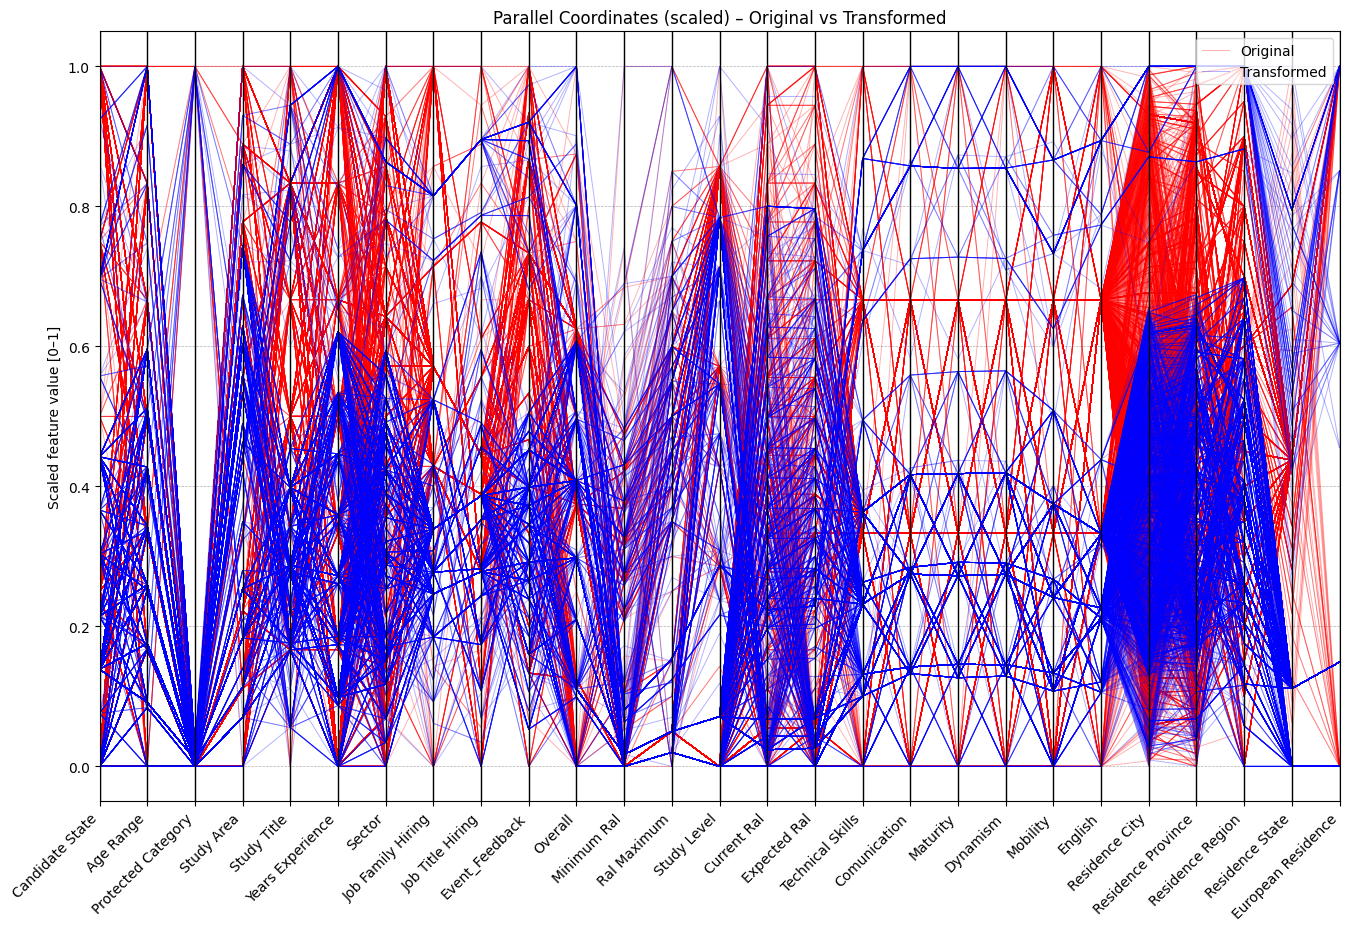

In [229]:
X_orig_df = X_train.copy()
X_orig_df.drop(columns=sensitive, inplace=True)
X_trans_df = X_train_cr.copy()

scaler = MinMaxScaler()
X_orig_df_scaled = pd.DataFrame(
    scaler.fit_transform(X_orig_df),
    columns=X_orig_df.columns,
    index=X_orig_df.index
)
X_trans_df_scaled = pd.DataFrame(
    scaler.fit_transform(X_trans_df),
    columns=X_trans_df.columns,
    index=X_trans_df.index
)

X_trans_df_scaled.columns = X_orig_df_scaled.columns
X_orig_df_scaled['version'] = 'Original'
X_trans_df_scaled['version'] = 'Transformed'

df_combined_scaled = pd.concat(
    [X_orig_df_scaled, X_trans_df_scaled],
    ignore_index=True
)

plt.figure(figsize=(16, 10))
parallel_coordinates(
    df_combined_scaled,
    class_column='version',
    cols=list(X_orig_df.columns),
    color=['red', 'blue'],
    alpha=0.3,
    linewidth=0.7
)

plt.title("Parallel Coordinates (scaled) – Original vs Transformed")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Scaled feature value [0–1]")
plt.grid(axis='y', linestyle='--', linewidth=0.5)

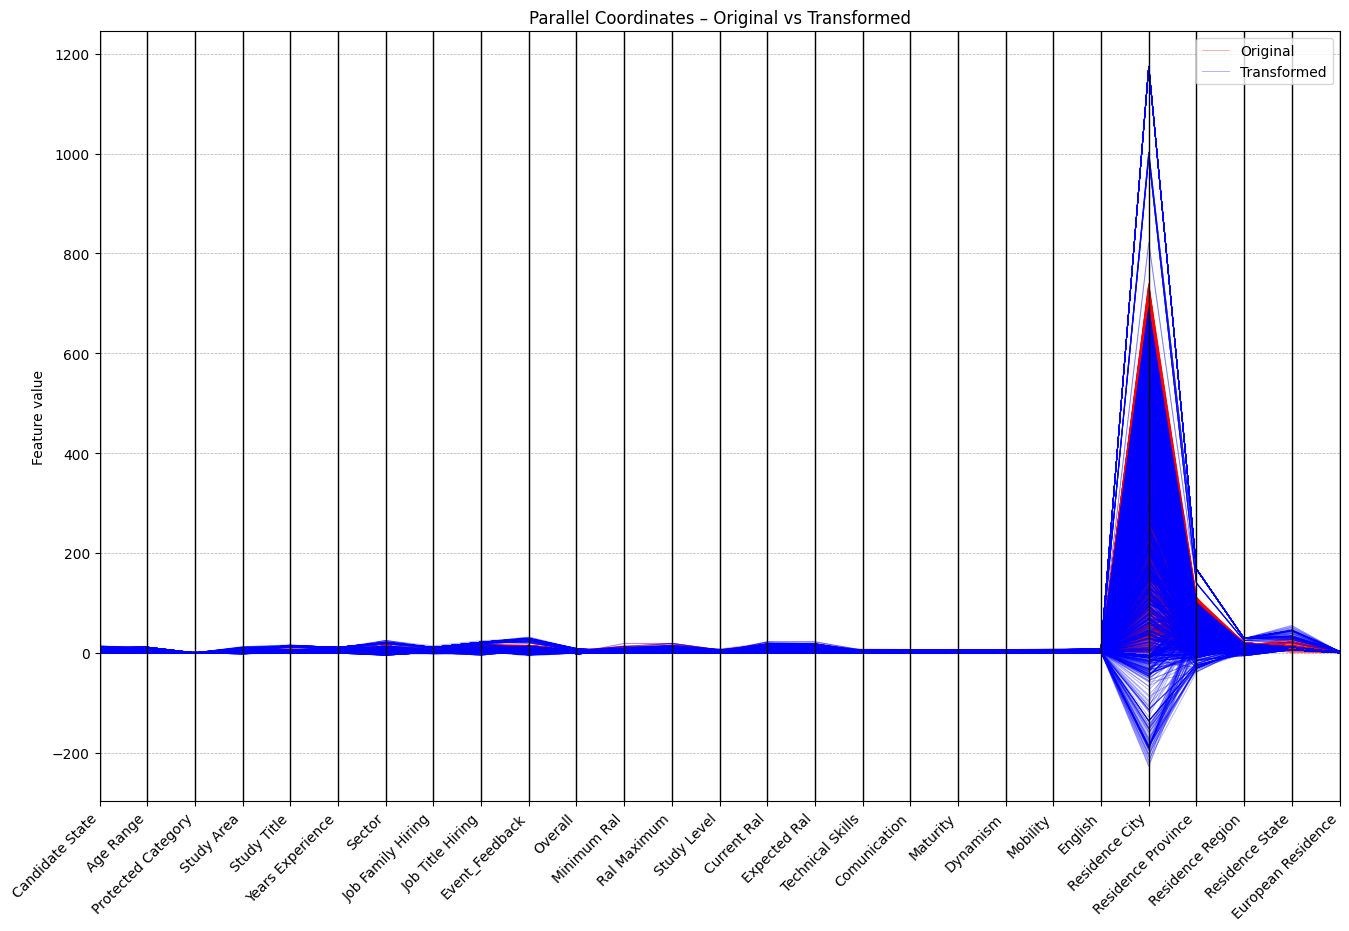

In [230]:
X_orig_df = X_train.copy()
X_orig_df.drop(columns=sensitive, inplace=True)
X_trans_df = X_train_cr.copy()

X_trans_df.columns = X_orig_df.columns
X_orig_df['version'] = 'Original'
X_trans_df['version'] = 'Transformed'

df_combined = pd.concat([X_orig_df, X_trans_df], ignore_index=True)

plt.figure(figsize=(16, 10))
parallel_coordinates(
    df_combined,
    class_column='version',
    cols= df_combined.columns[:-1],  # Exclude 'version' column
    color=['red', 'blue'],      # Original→red, Transformed→blue
    alpha=0.3,                  # transparency to see overlap
    linewidth=0.7
)

plt.title("Parallel Coordinates – Original vs Transformed")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Feature value")
plt.grid(axis='y', linestyle='--', linewidth=0.5)  # light horizontal grid

### In-Processing

In [231]:
models = {
    'Linear Regression': LinearRegression(),
}

In [232]:
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train, s_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    s_tr, s_va = s_train.iloc[tr_idx], s_train.iloc[va_idx]

    train_ds = to_aif360(X_tr, y_tr, s_tr)
    val_ds = to_aif360(X_va, y_va, s_va)

    for model_name, model in models.items():
        gfc = GerryFairClassifier(
            C=10,
            gamma=0.01,
            fairness_def='FP',
            max_iters=10,
            printflag=False,
            heatmapflag=False,
            heatmap_iter=10,
            heatmap_path='.',
            predictor=model
        )
        gfc.fit(train_ds)
        pred_gfc = gfc.predict(val_ds)
        predictions[(fold, f"{model_name}_inprocessed_gfc")] = pred_gfc.labels.ravel()

        references[(fold, f"{model_name}_inprocessed_gfc")] = y_va.values
        sensitives[(fold, f"{model_name}_inprocessed_gfc")] = s_va.values
        
        temp = predictions[(fold, f"{model_name}_inprocessed_gfc")]
        print(f"Inprocessed predictions for {model_name}: {temp}")


Inprocessed predictions for Linear Regression: [1 1 0 ... 0 0 1]
Inprocessed predictions for Linear Regression: [0 0 0 ... 0 0 0]
Inprocessed predictions for Linear Regression: [0 1 0 ... 0 0 0]
Inprocessed predictions for Linear Regression: [1 1 0 ... 0 0 1]
Inprocessed predictions for Linear Regression: [1 0 0 ... 0 0 1]
Inprocessed predictions for Linear Regression: [1 0 0 ... 0 0 0]


### Post-Processing

In [289]:
def create_model(seed, input_dim):
    tf.random.set_seed(seed)
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

models = {
    'Logistic Regression': LogisticRegression(),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(),
    'KNN': KNeighborsClassifier(),
    'Neural Network': create_model(random_seed, X_train.shape[1]),
}

In [290]:
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train, s_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    s_tr, s_va = s_train.iloc[tr_idx], s_train.iloc[va_idx]

    for model_name, model in models.items():
        print(f"Training {model_name}...")
        if model_name == 'Neural Network':
            model.fit(X_tr, y_tr, epochs=10, batch_size=32, verbose=0)
            predictions[(fold, f"{model_name}_postprocessed_to")] = model.predict(X_va).ravel()
        else:
            model.fit(X_tr, y_tr)
            predictions[(fold, f"{model_name}_postprocessed_to")] = model.predict(X_va).ravel()

        print(f"{model_name} trained.")

    for model_name, model in models.items():
        to = ThresholdOptimizer(
            estimator=model,
            constraints='demographic_parity',
            objective='accuracy_score',
            prefit=True,
            grid_size=1000,
            flip=False,
            predict_method='predict'
        )
        to.fit(X_tr, y_tr, sensitive_features=s_tr)
        pred_to = to.predict(X_va, sensitive_features=s_va)
        predictions[(fold, f"{model_name}_postprocessed_to")] = pred_to.ravel()

        references[(fold, f"{model_name}_postprocessed_to")] = y_va.values
        sensitives[(fold, f"{model_name}_postprocessed_to")] = s_va.values
        
        temp = predictions[(fold, f"{model_name}_postprocessed_to")]
        print(f"Postprocessed predictions for {model_name}: {temp}")

Training Logistic Regression...
Logistic Regression trained.
Training Linear Regression...
Linear Regression trained.
Training Decision Tree...
Decision Tree trained.
Training Naive Bayes...


c:\Users\andre\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Naive Bayes trained.
Training XGBoost...
XGBoost trained.
Training KNN...
KNN trained.
Training Neural Network...
41/41 [==============================] - 0s 2ms/step
Neural Network trained.


ValueError: Degenerate labels for sensitive feature value 0,0

## Save

In [235]:
serializable_data = {
  'predictions': predictions,
  'references':  references,
  'sensitives':  sensitives,
  'sensitive_name': sensitive,
}

print("Predictions:")
for (fold, model_name), preds in predictions.items():
    label = f"Fold {fold} – {model_name}"
    print(f"{label:<40}\t{preds[:30].tolist()} ...")

print("References:")
for (fold, model_name), ref in references.items():
    label = f"Fold {fold} – {model_name}"
    print(f"{label:<40}\t{ref[:30].tolist()} ...")

print("Sensitives:")
for (fold, model_name), sens in sensitives.items():
    label = f"Fold {fold} – {model_name}"
    print(f"{label:<40}\t{sens[:30].tolist()} ...")

print(f"Sensitive name: {sensitive}")


Predictions:
Fold 1 – Logistic Regression            	[1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0] ...
Fold 1 – Linear Regression              	[1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0] ...
Fold 1 – Decision Tree                  	[1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1] ...
Fold 1 – Naive Bayes                    	[1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0] ...
Fold 1 – XGBoost                        	[1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1] ...
Fold 1 – KNN                            	[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
Fold 1 – Neural Network                 	[1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1] ...
Fold 2 – Logistic Regression       

In [236]:
with open(PATH + 'data/predictions', 'wb') as f:
  pickle.dump(serializable_data, f)